# Path-Length Matching

Path-length matching equalises the optical (or electrical) path lengths across a bundle
of routes.  When routes travel different distances — because start ports are staggered,
or end ports are not symmetric — the shorter routes get small "squiggle" loops inserted
so that every waveguide in the bundle reaches the same total length.

**Why it matters:**

- **Optical coherence** — interferometers and phased arrays require equal path lengths to
  within a fraction of a wavelength.
- **Signal timing** — electrical buses must arrive at the same time; unequal lengths cause
  skew.
- **Array uniformity** — grating coupler arrays and detector arrays often require matched
  lengths for balanced response.

## How it works in kfactory

Pass `kf.PathLengthMatch(...)` as a routing **constraint** to `route_bundle`, and
tag the bundle with `route_name=`.  After the backbones are computed but before any
instances are placed, the constraint runs `path_length_match` over the routers
whose `route_name` it matches.  It measures the longest router in the matched set,
then inserts a "squiggle" loop (a 4-point detour made from two 90° bends) into
each shorter router until all lengths are equal.

## Setup

In [1]:
from functools import partial

import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGCLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)


L = LAYER()
kf.kcl.infos = L

wg_enc = kf.kcl.get_enclosure(
    kf.LayerEnclosure(name="WGSTD_PLM", sections=[(L.WGCLAD, 0, 2_000)])
)

# Euler bend — width and radius in µm
bend90 = kf.factories.euler.bend_euler_factory(kcl=kf.kcl)(
    width=0.5,
    radius=10,
    layer=L.WG,
    enclosure=wg_enc,
    angle=90,
)

# Straight factory — width and length in DBU
straight_factory = partial(
    kf.factories.straight.straight_dbu_factory(kcl=kf.kcl),
    layer=L.WG,
    enclosure=wg_enc,
)

WG_WIDTH = kf.kcl.to_dbu(0.5)  # 500 DBU

# Effective routing radius of the euler bend (larger than the nominal 10 µm)
bend_radius = kf.routing.optical.get_radius(bend90)

## 1 · Baseline — unequal path lengths

Three North-facing start ports are staggered vertically (each 200 µm shorter than the
previous) so that each route naturally has a different path length.  Without
path-length matching the routes reach their end ports at different total lengths.

Unmatched lengths (µm): [558.0, 738.0, 868.0]


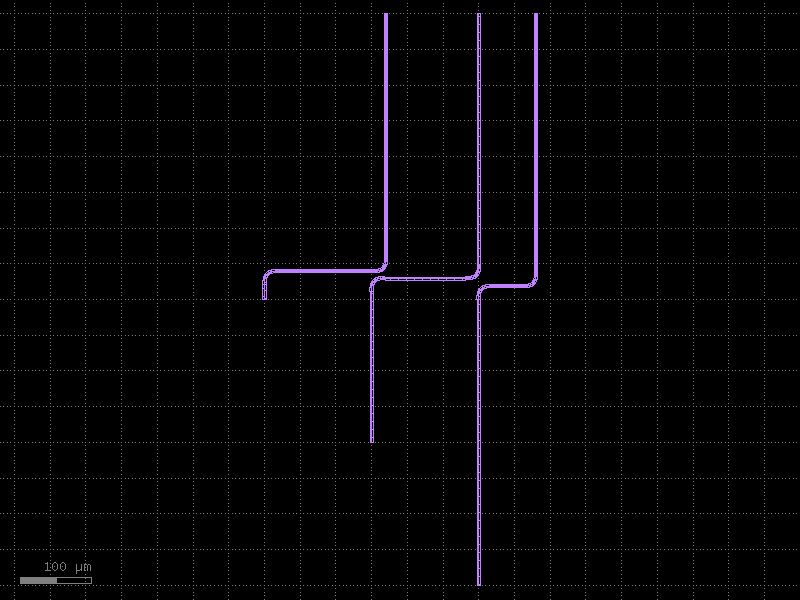

In [2]:
c_baseline = kf.KCell("plm_baseline")

# Staggered starts: port 0 is longest, port 2 is shortest
baseline_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 150), kf.kcl.to_dbu(-i * 200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
baseline_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(x), kf.kcl.to_dbu(400)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i, x in enumerate([170, 300, 380])
]

routes_baseline = kf.routing.optical.route_bundle(
    c_baseline,
    baseline_starts,
    baseline_ends,
    separation=kf.kcl.to_dbu(10),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    on_collision=None,
)

print("Unmatched lengths (µm):", [round(r.length / 1000, 1) for r in routes_baseline])
c_baseline

The three routes have clearly different lengths.  Path-length matching will bring them
all to the longest value.

## 2 · Basic path-length matching

Pass `constraints=[kf.PathLengthMatch(route_names=["..."], element=-1, loop_side=-1,
loops=1, loop_position=0)]` plus `route_name="..."` to insert loops in the last
backbone segment (`element=-1`), on the left side, centered in the segment.

Matched lengths (µm): [918.9, 918.9, 918.9]


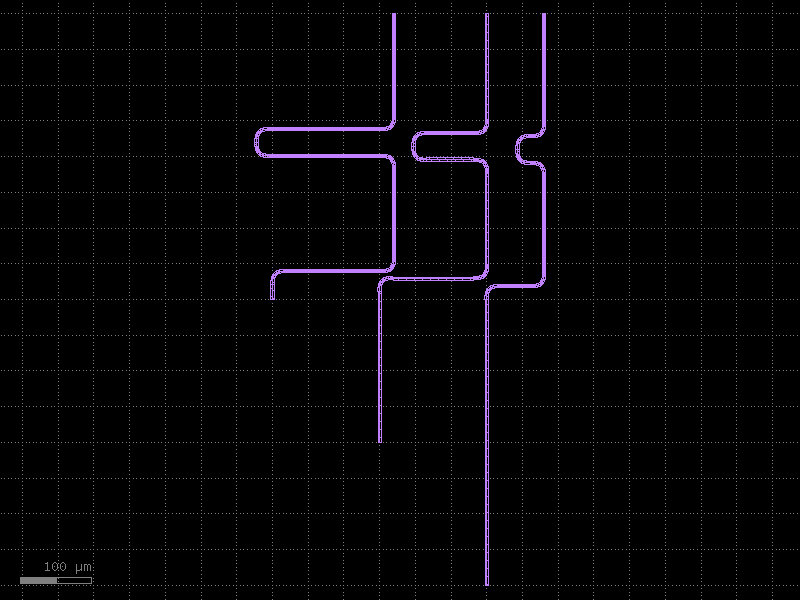

In [3]:
c_plm = kf.KCell("plm_basic")

plm_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 150), kf.kcl.to_dbu(-i * 200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
plm_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(x), kf.kcl.to_dbu(400)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i, x in enumerate([170, 300, 380])
]

routes_plm = kf.routing.optical.route_bundle(
    c_plm,
    plm_starts,
    plm_ends,
    separation=kf.kcl.to_dbu(10),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    on_collision=None,
    constraints=[
        kf.PathLengthMatch(
            route_names=["plm_basic"],
            element=-1,  # last backbone segment
            loop_side=-1,  # loops protrude to the left (-1=left, 0=center, 1=right)
            loops=1,  # one squiggle loop per route
            loop_position=0,  # loop is centered in the segment
        )
    ],
    route_name="plm_basic",
)

print("Matched lengths (µm):", [round(r.length / 1000, 1) for r in routes_plm])
c_plm

All three routes now have equal total length.  The shorter routes received progressively
taller squiggle loops.

## 3 · `loop_side` — which side the loop protrudes

| Value | Enum | Effect |
|---|---|---|
| `-1` | `LoopSide.left` | Loop extends to the left of the route direction |
| `0` | `LoopSide.center` | Loop is split symmetrically above and below |
| `1` | `LoopSide.right` | Loop extends to the right of the route direction |

For routes running northward, "left" means west and "right" means east.  Choose the
side that avoids neighbouring structures.

### loop_side = right

Right-side loops protrude east, *into* the space of the next route in the bundle,
so the routes need to be closer in path length than for left/center loops.  Here
we halve the y-stagger (`100` µm instead of `200`) so the squiggle stays compact
enough to clear the neighbour — verifiable with `c.connectivity_check()`.

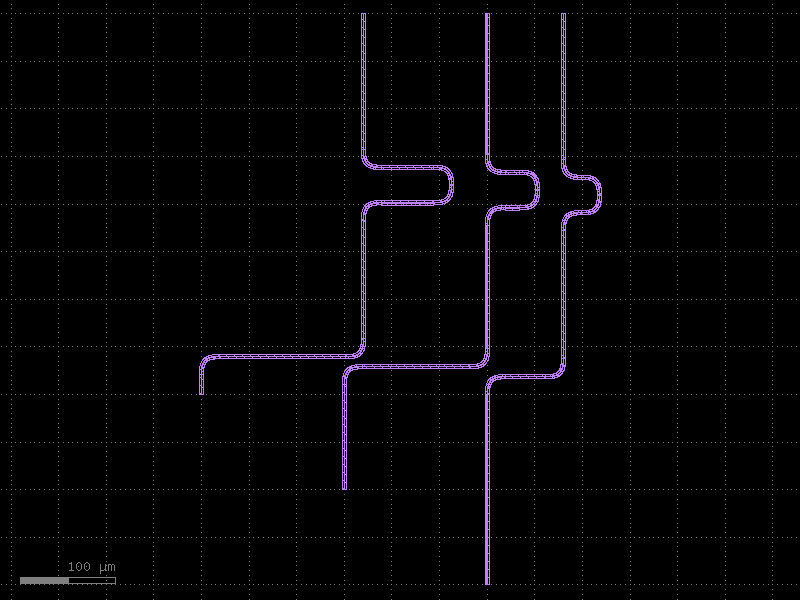

In [4]:
c_right = kf.KCell("plm_loop_right")

rs_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 150), kf.kcl.to_dbu(-i * 100)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
rs_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(x), kf.kcl.to_dbu(400)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i, x in enumerate([170, 300, 380])
]

kf.routing.optical.route_bundle(
    c_right,
    rs_starts,
    rs_ends,
    separation=kf.kcl.to_dbu(10),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    on_collision=None,
    constraints=[
        kf.PathLengthMatch(
            route_names=["plm_right"],
            element=-1,
            loop_side=1,  # ← right
            loops=1,
            loop_position=0,
        )
    ],
    route_name="plm_right",
)
c_right

### loop_side = center (symmetric)

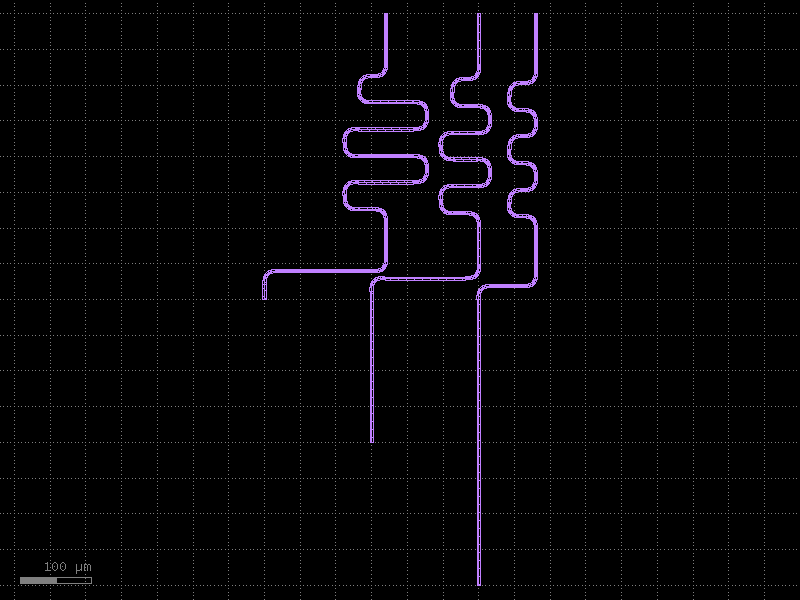

In [5]:
c_center = kf.KCell("plm_loop_center")

lc_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 150), kf.kcl.to_dbu(-i * 200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
lc_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(x), kf.kcl.to_dbu(400)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i, x in enumerate([170, 300, 380])
]

kf.routing.optical.route_bundle(
    c_center,
    lc_starts,
    lc_ends,
    separation=kf.kcl.to_dbu(10),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    on_collision=None,
    constraints=[
        kf.PathLengthMatch(
            route_names=["plm_center"],
            element=-1,
            loop_side=0,  # ← center (symmetric around route axis)
            loops=1,
            loop_position=0,
        )
    ],
    route_name="plm_center",
)
c_center

## 4 · `loop_position` — where in the segment the loop sits

| Value | Enum | Effect |
|---|---|---|
| `-1` | `LoopPosition.start` | Loop is placed near the start of the backbone segment |
| `0` | `LoopPosition.center` | Loop is centered in the backbone segment |
| `1` | `LoopPosition.end` | Loop is placed near the end of the backbone segment |

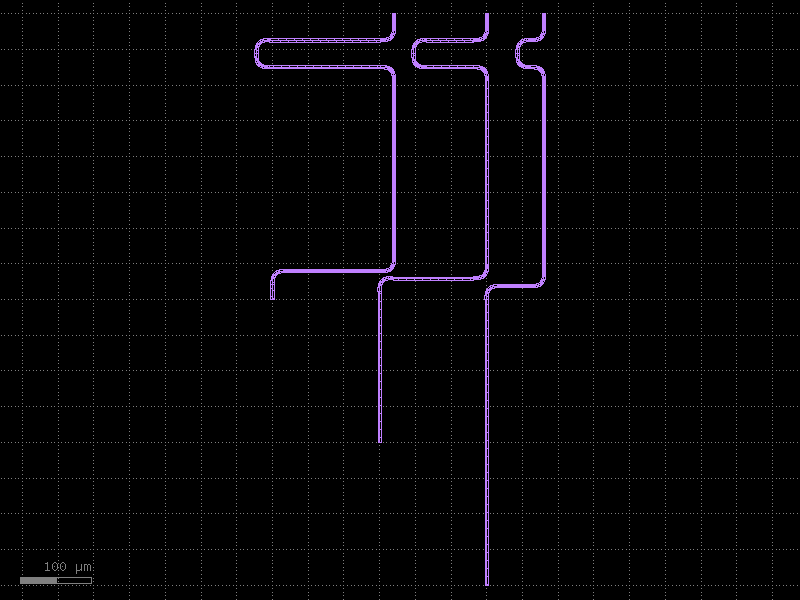

In [6]:
c_pos_end = kf.KCell("plm_loop_pos_end")

pe_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 150), kf.kcl.to_dbu(-i * 200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
pe_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(x), kf.kcl.to_dbu(400)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i, x in enumerate([170, 300, 380])
]

kf.routing.optical.route_bundle(
    c_pos_end,
    pe_starts,
    pe_ends,
    separation=kf.kcl.to_dbu(10),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    on_collision=None,
    constraints=[
        kf.PathLengthMatch(
            route_names=["plm_pos_end"],
            element=-1,
            loop_side=-1,
            loops=1,
            loop_position=1,  # ← near the end of the segment
        )
    ],
    route_name="plm_pos_end",
)
c_pos_end

## 5 · `loops` — multiple squiggle repetitions

When the length difference between the shortest and longest route is large, a single
loop may become very tall.  Increasing `loops` splits the extra length across multiple
smaller squiggles, which keeps the loop footprint compact and avoids collision with
neighbouring structures.

Matched lengths (µm): [969.7, 969.7, 969.7]


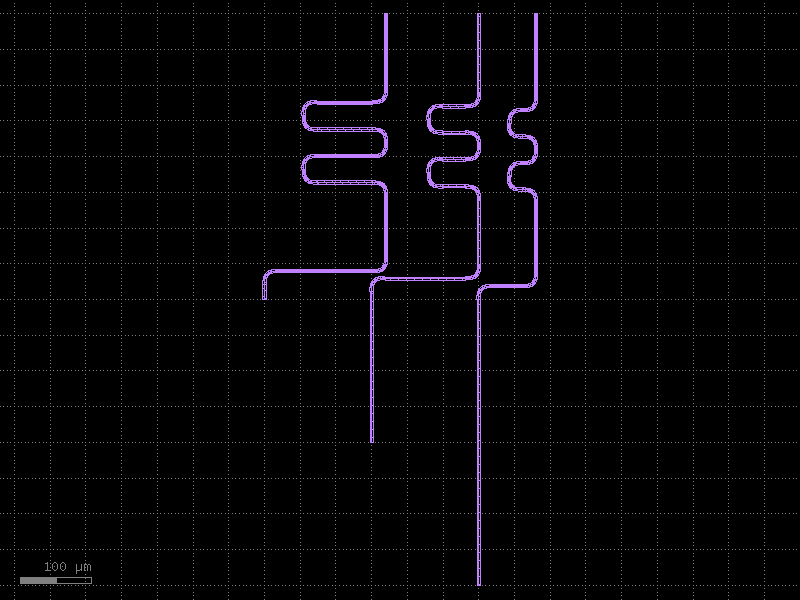

In [7]:
c_loops2 = kf.KCell("plm_loops_2")

l2_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 150), kf.kcl.to_dbu(-i * 200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
l2_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(x), kf.kcl.to_dbu(400)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i, x in enumerate([170, 300, 380])
]

routes_l2 = kf.routing.optical.route_bundle(
    c_loops2,
    l2_starts,
    l2_ends,
    separation=kf.kcl.to_dbu(10),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    on_collision=None,
    constraints=[
        kf.PathLengthMatch(
            route_names=["plm_loops_2"],
            element=-1,
            loop_side=-1,
            loops=2,  # ← two squiggle loops per route
            loop_position=0,
        )
    ],
    route_name="plm_loops_2",
)

print("Matched lengths (µm):", [round(r.length / 1000, 1) for r in routes_l2])
c_loops2

## 6 · Inspecting route lengths

`route_bundle` returns a list of `ManhattanRoute` objects.  Each route exposes
several length properties that are useful for diagnostics:

| Attribute | Description |
|---|---|
| `route.length` | Total path length in µm (straights + bend arclengths) |
| `route.length_backbone` | Straight-line length of the backbone |
| `route.length_straights` | Summed length of all straight segments only |
| `route.n_bend90` | Number of 90° bends placed |
| `route.n_taper` | Number of taper transitions placed |

In [8]:
c_inspect = kf.KCell("plm_inspect")

ins_starts = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 150), kf.kcl.to_dbu(-i * 200)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i in range(3)
]
ins_ends = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(x), kf.kcl.to_dbu(400)),
        width=WG_WIDTH,
        layer_info=L.WG,
    )
    for i, x in enumerate([170, 300, 380])
]

routes_ins = kf.routing.optical.route_bundle(
    c_inspect,
    ins_starts,
    ins_ends,
    separation=kf.kcl.to_dbu(10),
    straight_factory=straight_factory,
    bend90_cell=bend90,
    on_collision=None,
    constraints=[
        kf.PathLengthMatch(
            route_names=["plm_inspect"],
            element=-1,
            loop_side=-1,
            loops=1,
            loop_position=0,
        )
    ],
    route_name="plm_inspect",
)

print(f"{'Route':<8} {'length (µm)':>14} {'straights (µm)':>16} {'n_bend90':>10}")
print("-" * 52)
for i, r in enumerate(routes_ins):
    print(
        f"  {i:<6} {r.length / 1000:>13.3f}"
        f" {r.length_straights / 1000:>15.3f}"
        f" {r.n_bend90:>10}"
    )

Route       length (µm)   straights (µm)   n_bend90
----------------------------------------------------
  0            918.882         730.392          6
  1            918.882         730.392          6
  2            918.882         730.392          6


All routes share the same total `length`.  The shorter routes have longer `length_straights`
(the loop adds extra straight segments) and more `n_bend90` (the loop uses four bends).

## 7 · Choosing the right backbone segment (`element`)

The `element` key selects which segment of the backbone gets the loop inserted:

- `element=-1` — last segment (before the end port).  Best when the end region has
  ample space and the longest straight is near the end.
- `element=0` — first segment (after the start port).  Useful when the start region
  is spacious.
- Other integers index into the backbone point list.

The segment must be long enough to contain the loop.  A segment shorter than
`4 × bend_radius` cannot hold a single loop; the router will place the loop but the
geometry may become cramped.

## Summary

`kf.PathLengthMatch` fields:

| Field | Type | Meaning |
|---|---|---|
| `route_names` | `list[str]` | `route_name`s of the bundles to equalise |
| `element` | `int` | Backbone segment index. `-1` = last, `0` = first. |
| `loop_side` | `int` | `-1` left, `0` center (symmetric), `1` right |
| `loops` | `int` | Number of squiggle repetitions per route |
| `loop_position` | `int` | `-1` near start, `0` center, `1` near end of segment |
| `length` | `int \| None` | Target path length (DBU). `None` = match longest. |
| `tolerance` | `int` | Maximum allowed length spread (DBU) after enforcement |

**Practical tips:**

- Horizontal separation between routes must be ≥ 2× `bend_radius` so loops do not
  overlap adjacent waveguides.
- For large length differences use `loops=2` or `loops=3` to keep loop heights compact.
- Use `route.length` after routing to verify that all routes are matched.
- Pass `on_collision=None` in scripts and doc builds to suppress the KLayout error
  dialog when collision geometry is not critical.

## See Also

| Topic | Where |
|-------|-------|
| Bundle routing that `kf.PathLengthMatch` plugs into | [Routing: Bundle](bundle.py) |
| Optical route options including waypoints and stubs | [Routing: Optical](optical.py) |
| Routing overview and sub-module map | [Routing: Overview](overview.py) |
| Euler bend effective radius (affects loop spacing) | [Components: Euler Bends](../components/cells/factories/euler.py) |
| DBU vs µm (route.length is in µm) | [Core Concepts: DBU vs µm](../concepts/dbu_vs_um.py) |